In [5]:
import * as tslab from "tslab";
import { readFileSync } from "fs";

const css = readFileSync("../style.css", "utf-8");
tslab.display.html(`<style>${css}</style>`);

node:fs:448
    return binding.readFileUtf8(path, stringToFlags(options.flag));
                   ^

Error: ENOENT: no such file or directory, open 'C:\Users\style.css'
    at readFileSync (node:fs:448:20)
    at evalmachine.<anonymous>:30:35
    at evalmachine.<anonymous>:34:3
    at sigintHandlersWrap (node:vm:279:12)
    at Script.runInThisContext (node:vm:134:14)
    at Object.runInThisContext (node:vm:316:38)
    at Object.execute (C:\Users\leo\anaconda3\node_modules\tslab\dist\executor.js:160:38)
    at JupyterHandlerImpl.handleExecuteImpl (C:\Users\leo\anaconda3\node_modules\tslab\dist\jupyter.js:250:38)
    at C:\Users\leo\anaconda3\node_modules\tslab\dist\jupyter.js:208:57
    at async JupyterHandlerImpl.handleExecute (C:\Users\leo\anaconda3\node_modules\tslab\dist\jupyter.js:208:21) {
  errno: -4058,
  code: 'ENOENT',
  syscall: 'open',
  path: 'C:\\Users\\style.css'
}


# The Fibonacci Numbers

The [Fibonacci numbers](https://en.wikipedia.org/wiki/Fibonacci_number) $F_n$ are defined by induction for all $n\in\mathbb{N}$:
  - $F_0 := 0$,
  - $F_1 := 1$, 
  - $F_{n+2} = F_{n+1} + F_n$ for all $n \in \mathbb{N}$.

Given a natural number `n`, the function `fibonacci(n)` computes the number $F_n$.

In [1]:
function fibonacci(n: number): number {
  if (n <= 1) {
    return n;
  }
  return fibonacci(n - 1) + fibonacci(n - 2);
}

In [2]:
const values: [number, number][] = [];
for (let n = 0; n < 19; n++) {
  values.push([n, fibonacci(n)]);
}

console.log(values);

[
  [ 0, 0 ],     [ 1, 1 ],
  [ 2, 1 ],     [ 3, 2 ],
  [ 4, 3 ],     [ 5, 5 ],
  [ 6, 8 ],     [ 7, 13 ],
  [ 8, 21 ],    [ 9, 34 ],
  [ 10, 55 ],   [ 11, 89 ],
  [ 12, 144 ],  [ 13, 233 ],
  [ 14, 377 ],  [ 15, 610 ],
  [ 16, 987 ],  [ 17, 1597 ],
  [ 18, 2584 ]
]


It seems that the *Fibonacci numbers* grow pretty fast. Let us plot these numbers to get a better understanding of their growth.

In [3]:
import { ChartJSNodeCanvas } from "chartjs-node-canvas";
import { Chart, registerables, ChartConfiguration } from "chart.js";
import { display } from "tslab";


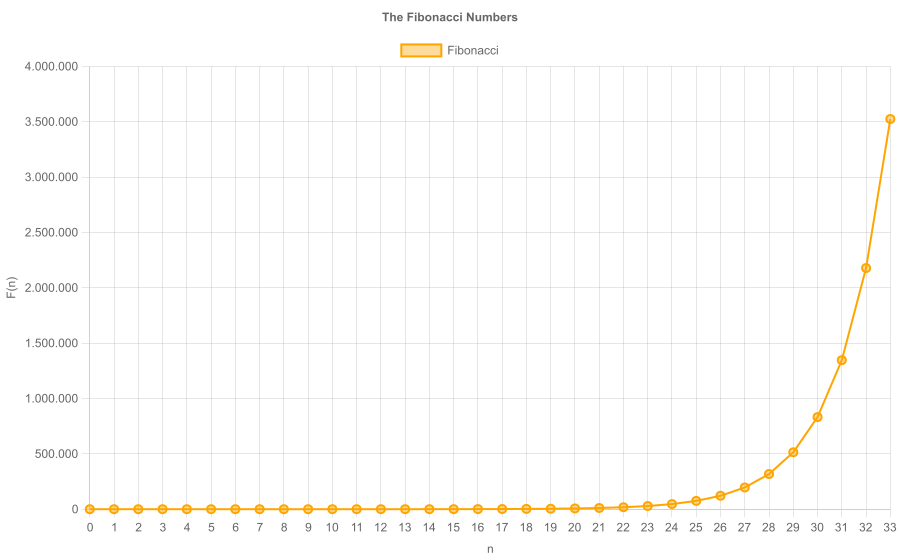

In [4]:
Chart.register(...registerables);

const m = 34;
const X = Array.from({ length: m }, (_, n) => n);
const Y = X.map(fibonacci);

const width = 900;
const height = 560;
const chartJSNodeCanvas = new ChartJSNodeCanvas({
  width,
  height,
  backgroundColour: "white",
});

const config: ChartConfiguration<"line", number[], string> = {
  type: "line",
  data: {
    labels: X.map(String),
    datasets: [
      {
        label: "Fibonacci",
        data: Y,
        pointRadius: 4,
        borderWidth: 2,
        borderColor: "rgb(255,165,0)",
        backgroundColor: "rgba(255,165,0,0.4)",
      },
    ],
  },
  options: {
    plugins: {
      title: { display: true, text: "The Fibonacci Numbers" },
    },
    scales: {
      x: { title: { display: true, text: "n" } },
      y: { title: { display: true, text: "F(n)" } },
    },
  },
};

const buffer = await chartJSNodeCanvas.renderToBuffer(config, "image/png");
const base64 = buffer.toString("base64");
const html = `<img src="data:image/png;base64,${base64}" alt="Fibonacci Chart" />`;
display.html(html);

It looks like the *Fibonacci numbers* grow exponentially.  Let us confirm this hypothesis by plotting the logarithm of these numbers.


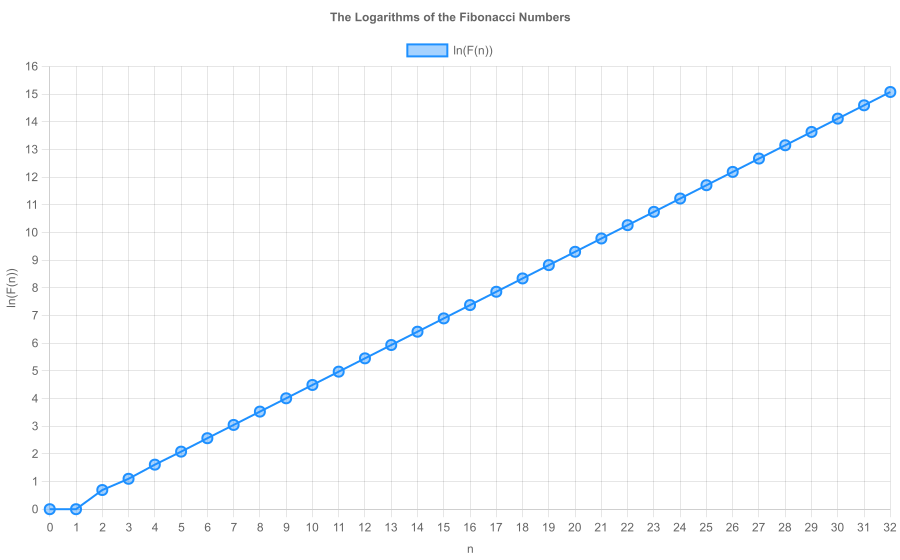

In [5]:
Chart.register(...registerables);

const X1 = X.slice(1);
const Y1 = Y.slice(1);

const logY = Y1.map(y => Math.log(y));

const width = 900;
const height = 560;
const chartJSNodeCanvas = new ChartJSNodeCanvas({
  width,
  height,
  backgroundColour: "white",
});

const config: ChartConfiguration<"line", number[], string> = {
  type: "line",
  data: {
    labels: X1.map(String),
    datasets: [
      {
        label: "ln(F(n))",
        data: logY,
        borderColor: "rgb(30,144,255)",
        backgroundColor: "rgba(30,144,255,0.4)",
        pointRadius: 5,
        borderWidth: 2,
        tension: 0, 
      },
    ],
  },
  options: {
    plugins: {
      title: {
        display: true,
        text: "The Logarithms of the Fibonacci Numbers",
      },
    },
    scales: {
      x: {
        title: { display: true, text: "n" },
        ticks: { callback: (val) => val.toString() },
      },
      y: {
        title: { display: true, text: "ln(F(n))" },
        ticks: { stepSize: 1 },
      },
    },
  },
};

const buffer = await chartJSNodeCanvas.renderToBuffer(config, "image/png");
const base64 = buffer.toString("base64");
const html = `<img src="data:image/png;base64,${base64}" alt="Logarithmic Fibonacci Chart" />`;
display.html(html);

This plot looks linear and confirms our hypothesis that these numbers grow exponentially.

Computing the *Fibonacci numbers* took quite long.  Lets measure these times and plot them.

In [6]:
const x = 1;
const y = 2;
`${x} + ${y} = ${x + y}`;

1 + 2 = 3


fib(0) = 0
0.000790
fib(1) = 1
0.000304
fib(2) = 1
0.000440
fib(3) = 2
0.000548
fib(4) = 3
0.000499
fib(5) = 5
0.000419
fib(6) = 8
0.000304
fib(7) = 13
0.000260
fib(8) = 21
0.000518
fib(9) = 34
0.000557
fib(10) = 55
0.000309
fib(11) = 89
0.000235
fib(12) = 144
0.000433
fib(13) = 233
0.000506
fib(14) = 377
0.000413
fib(15) = 610
0.000315
fib(16) = 987
0.000721
fib(17) = 1597
0.000793
fib(18) = 2584
0.000361
fib(19) = 4181
0.000362
fib(20) = 6765
0.000437
fib(21) = 10946
0.000747
fib(22) = 17711
0.000860
fib(23) = 28657
0.001158
fib(24) = 46368
0.002171
fib(25) = 75025
0.002614
fib(26) = 121393
0.003684
fib(27) = 196418
0.005281
fib(28) = 317811
0.007744
fib(29) = 514229
0.011979
fib(30) = 832040
0.048062
fib(31) = 1346269
0.045902
fib(32) = 2178309
0.063123
fib(33) = 3524578
0.109910
fib(34) = 5702887
0.178752
fib(35) = 9227465
0.236830



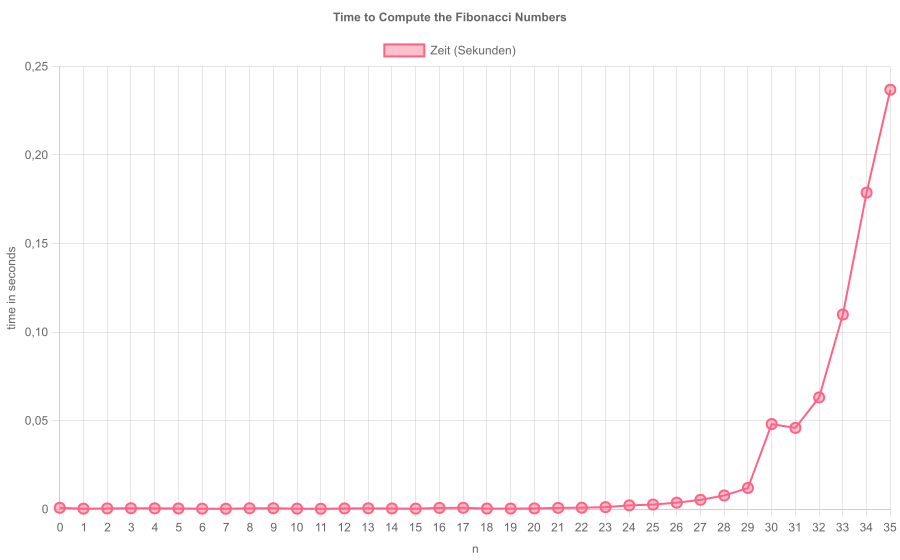

In [7]:
Chart.register(...registerables);

function fibonacci(n: number): number {
  return n <= 1 ? n : fibonacci(n - 1) + fibonacci(n - 2);
}

const m = 36;
const X = Array.from({ length: m }, (_, n) => n);
const Y: number[] = [];

for (const n of X) {
  const start = performance.now(); 
  console.log(`fib(${n}) = ${fibonacci(n)}`);
  const stop = performance.now(); 
  const elapsed = (stop - start) / 1000; 
  console.log(elapsed.toFixed(6));
  Y.push(elapsed);
}

const width = 900;
const height = 560;
const chartJSNodeCanvas = new ChartJSNodeCanvas({
  width,
  height,
  backgroundColour: "white",
});

const config: ChartConfiguration<"line", number[], string> = {
  type: "line",
  data: {
    labels: X.map(String),
    datasets: [
      {
        label: "Zeit (Sekunden)",
        data: Y,
        borderColor: "rgb(255,99,132)",
        backgroundColor: "rgba(255,99,132,0.4)",
        pointRadius: 5,
        borderWidth: 2,
      },
    ],
  },
  options: {
    plugins: {
      title: {
        display: true,
        text: "Time to Compute the Fibonacci Numbers",
      },
    },
    scales: {
      x: { title: { display: true, text: "n" } },
      y: { title: { display: true, text: "time in seconds" } },
    },
  },
};

const buffer = await chartJSNodeCanvas.renderToBuffer(config, "image/png");
const base64 = buffer.toString("base64");
const html = `<img src="data:image/png;base64,${base64}" alt="Fibonacci Performance Chart" />`;
display.html(html);


The times seem to grow exponentially.  


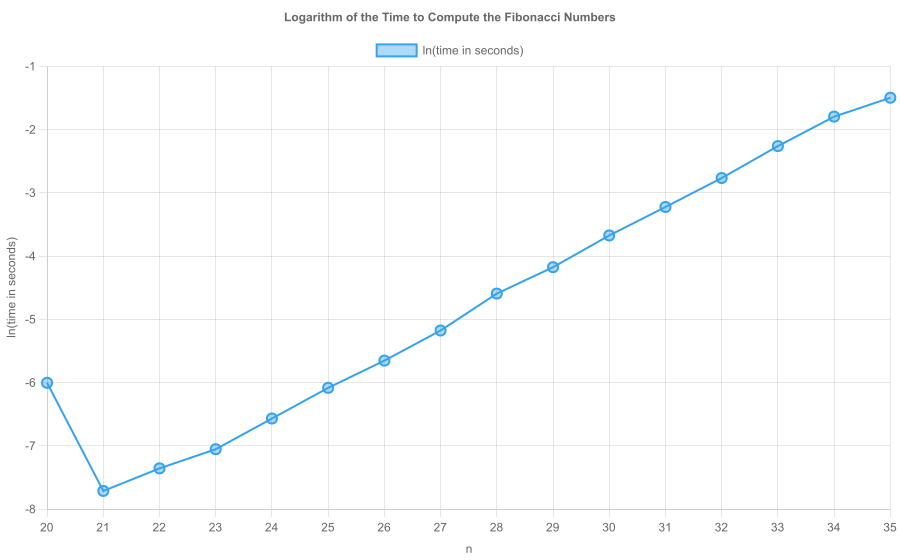

In [8]:
Chart.register(...registerables);

function fibonacci(n: number): number {
  return n <= 1 ? n : fibonacci(n - 1) + fibonacci(n - 2);
}

const m = 36;
const X = Array.from({ length: m - 20 }, (_, i) => i + 20);
const Y: number[] = [];

for (const n of X) {
  const start = performance.now(); 
  fibonacci(n);
  const stop = performance.now();
  const elapsedSeconds = (stop - start) / 1000;
  const logElapsed = Math.log(elapsedSeconds);
  Y.push(logElapsed);
}

const width = 900;
const height = 560;
const chartJSNodeCanvas = new ChartJSNodeCanvas({
  width,
  height,
  backgroundColour: "white",
});

const config: ChartConfiguration<"line", number[], string> = {
  type: "line",
  data: {
    labels: X.map(String),
    datasets: [
      {
        label: "ln(time in seconds)",
        data: Y,
        borderColor: "rgb(54,162,235)",
        backgroundColor: "rgba(54,162,235,0.4)",
        pointRadius: 5,
        borderWidth: 2,
        tension: 0,
      },
    ],
  },
  options: {
    plugins: {
      title: {
        display: true,
        text: "Logarithm of the Time to Compute the Fibonacci Numbers",
      },
    },
    scales: {
      x: { title: { display: true, text: "n" } },
      y: { title: { display: true, text: "ln(time in seconds)" } },
    },
  },
};

const buffer = await chartJSNodeCanvas.renderToBuffer(config, "image/png");
const base64 = buffer.toString("base64");
const html = `<img src="data:image/png;base64,${base64}" alt="Logarithmic Fibonacci Time Chart" />`;
display.html(html);

The logarithmic plot confirms this.  In order to investigate the reason for this exponential growth, we compute the *computation tree*.  This tree shows the recursive invocations of the function.

In [9]:
import { Graphviz } from "@hpcc-js/wasm";

In [10]:
import { display } from "tslab";
import { Graphviz } from "@hpcc-js/wasm";

class ComputationTree {
  static sCounter = 0;
  mID?: number;

  constructor(
    public mArg: number,
    public mValue: number,
    public mLeft: ComputationTree | null = null,
    public mRight: ComputationTree | null = null
  ) {}

  isLeaf(): boolean {
    return this.mLeft === null && this.mRight === null;
  }

  toDot(): string {
    ComputationTree.sCounter = 0;
    const nodeMap = new Map<number, ComputationTree>();
    this._assignIDs(nodeMap);

    const lines: string[] = [];
    lines.push("digraph G {");
    lines.push('  node [shape=record, style="rounded"];');

    for (const [n, t] of nodeMap) {
      lines.push(`  ${n} [label="{${t.mArg}|${t.mValue}}"];`);
      if (t.mLeft && t.mRight) {
        lines.push(`  ${n} -> ${t.mLeft.mID};`);
        lines.push(`  ${n} -> ${t.mRight.mID};`);
      }
    }
    lines.push("}");
    return lines.join("\n");
  }

  private _assignIDs(nodeMap: Map<number, ComputationTree>): void {
    ComputationTree.sCounter += 1;
    this.mID = ComputationTree.sCounter;
    nodeMap.set(this.mID, this);
    if (this.isLeaf()) return;
    this.mLeft!._assignIDs(nodeMap);
    this.mRight!._assignIDs(nodeMap);
  }
}

function fibonacci_tree(n: number): ComputationTree {
  if (n <= 1) return new ComputationTree(n, n);
  const C1 = fibonacci_tree(n - 1);
  const C2 = fibonacci_tree(n - 2);
  return new ComputationTree(n, C1.mValue + C2.mValue, C1, C2);
}

const t = fibonacci_tree(6);
const dot = t.toDot();

const gv = await Graphviz.load();
const svg = gv.layout(dot, "svg", "dot");

display.html(svg);


<?xml version="1.0" encoding="UTF-8" standalone="no"?>
<!DOCTYPE svg PUBLIC "-//W3C//DTD SVG 1.1//EN"
 "http://www.w3.org/Graphics/SVG/1.1/DTD/svg11.dtd">
<!-- Generated by graphviz version 14.0.1 (0)
 -->
<!-- Title: G Pages: 1 -->
 
 
 G 
 
<!-- 1 -->
 
 1 
 
 6 
 
 8 
 
<!-- 2 -->
 
 2 
 
 5 
 
 5 
 
<!-- 1->2 -->
 
 1->2 
 
 
 
<!-- 17 -->
 
 17 
 
 4 
 
 3 
 
<!-- 1->17 -->
 
 1->17 
 
 
 
<!-- 3 -->
 
 3 
 
 4 
 
 3 
 
<!-- 2->3 -->
 
 2->3 
 
 
 
<!-- 12 -->
 
 12 
 
 3 
 
 2 
 
<!-- 2->12 -->
 
 2->12 
 
 
 
<!-- 18 -->
 
 18 
 
 3 
 
 2 
 
<!-- 17->18 -->
 
 17->18 
 
 
 
<!-- 23 -->
 
 23 
 
 2 
 
 1 
 
<!-- 17->23 -->
 
 17->23 
 
 
 
<!-- 4 -->
 
 4 
 
 3 
 
 2 
 
<!-- 3->4 -->
 
 3->4 
 
 
 
<!-- 9 -->
 
 9 
 
 2 
 
 1 
 
<!-- 3->9 -->
 
 3->9 
 
 
 
<!-- 13 -->
 
 13 
 
 2 
 
 1 
 
<!-- 12->13 -->
 
 12->13 
 
 
 
<!-- 16 -->
 
 16 
 
 1 
 
 1 
 
<!-- 12->16 -->
 
 12->16 
 
 
 
<!-- 5 -->
 
 5 
 
 2 
 
 1 
 
<!-- 4->5 -->
 
 4->5 
 
 
 
<!-- 8 -->
 
 8 
 
 1 
 
 1 
 
<!-- 4->8 -->
 
 4->8 
 
 
 
<!-- 10 -->
 
 10 
 
 1 
 
 1 
 
<!-- 9->10 -->
 
 9->10 
 
 
 
<!-- 11 -->
 
 11 
 
 0 
 
 0 
 
<!-- 9->11 -->
 
 9->11 
 
 
 
<!-- 6 -->
 
 6 
 
 1 
 
 1 
 
<!-- 5->6 -->
 
 5->6 
 
 
 
<!-- 7 -->
 
 7 
 
 0 
 
 0 
 
<!-- 5->7 -->
 
 5->7 
 
 
 
<!-- 14 -->
 
 14 
 
 1 
 
 1 
 
<!-- 13->14 -->
 
 13->14 
 
 
 
<!-- 15 -->
 
 15 
 
 0 
 
 0 
 
<!-- 13->15 -->
 
 13->15 
 
 
 
<!-- 19 -->
 
 19 
 
 2 
 
 1 
 
<!-- 18->19 -->
 
 18->19 
 
 
 
<!-- 22 -->
 
 22 
 
 1 
 
 1 
 
<!-- 18->22 -->
 
 18->22 
 
 
 
<!-- 24 -->
 
 24 
 
 1 
 
 1 
 
<!-- 23->24 -->
 
 23->24 
 
 
 
<!-- 25 -->
 
 25 
 
 0 
 
 0 
 
<!-- 23->25 -->
 
 23->25 
 
 
 
<!-- 20 -->
 
 20 
 
 1 
 
 1 
 
<!-- 19->20 -->
 
 19->20 
 
 
 
<!-- 21 -->
 
 21 
 
 0 
 
 0 
 
<!-- 19->21 -->
 
 19->21

The *computation tree* for the computation of `fibonacci(6)` shows the reason for the inefficiency:
* `fibonacci(5)` is computed once,
* `fibonacci(4)` is computed 2 times,
* `fibonacci(3)` is computed 3 times,
* `fibonacci(2)` is computed 5 times,
* `fibonacci(1)` is computed 8 times, and
* `fibonacci(0)` is computed 5 times.

If we want to compute the Fibonacci numbers efficiently, we must not compute the value `fibonacci(n)` for a given `n` more than once.  The easiest way to achieve this is by storing the Fibnacci numbers in a list `L`.  In the implementation below, `L[n]` stores the $n$-th Fibonacci number.

In [24]:
function fibonacci_mem(n: number): bigint {
  if (n <= 1) return BigInt(n);
  const L: bigint[] = new Array(n + 1).fill(0n);
  L[1] = 1n;
  for (let k = 2; k <= n; k++) {
    L[k] = L[k - 1] + L[k - 2];
  }
  return L[n];
}

Now it is even possible to compute the $100,000^\mbox{th}$ *Fibonnaci number*.

In [30]:
console.time("Evaluation Time");
const x = fibonacci_mem(100_000);
console.timeEnd("Evaluation Time");

Evaluation Time: 1.446s


In [31]:
x;

[...
